1896256


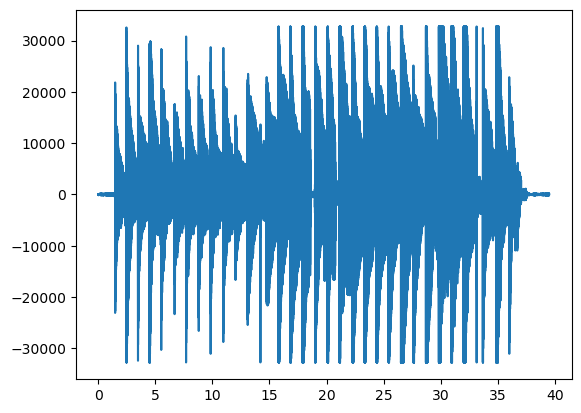

In [2]:
import wave
import numpy
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import filtfilt
from scipy import io
# open the audio file and extract some information
spf = wave.open('/home/gerald/workspace/src/GuitarMidi-LV2/assets/single-note/Guitar MIDI test.wav','r')
(nChannels, sampWidth, sampleRate, nFrames, compType, compName) = spf.getparams()

sampleRate,input_signal=io.wavfile.read('/home/gerald/workspace/src/GuitarMidi-LV2/assets/single-note/Guitar MIDI test.wav')
audio=input_signal[:,1];
print(len(audio))
nFrames =input_signal.shape[0]
time=numpy.linspace(0,len(audio)/sampleRate,len(audio))

plt.plot(time, audio, label='Input')



# # extract audio from wav file
# input_signal = spf.readframes(-1)


# input_signal = numpy.fromstring(input_signal)
# spf.close()



# # ceate output file
# wav_out = wave.open("output.wav", "w")
# wav_out.setparams((nChannels, sampWidth, sampleRate, nFrames, compType, compName))

# # write to output file
# wav_out.writeframes(output_signal.tobytes())
# wav_out.close()

# # plot the signals
# t = numpy.linspace(0, nFrames/sampWidth, nFrames, endpoint = False)
# plt.plot(t, input_signal, label='Input')
# plt.plot(t, output_signal, label='Output')
# plt.show()


In [ ]:
import numpy as np
class Filter:
    def __init__(self, center_freq, bw,sample_rate):
        
        self.sample_rate=sample_rate
            
        # create the filter
        N = 2
        nyq = 0.5 * sampleRate
        low = (center_freq-bw/2) / nyq
        high = (center_freq+bw/2) / nyq
        self.b, self.a = signal.butter(N, [low, high], btype='band')
        
    def process(self,input_audio):
        return signal.filtfilt(self.b, self.a, input_audio)


class HarmonicGroup:
    def __init__(self, center_freq, bw,sample_rate):
        self.harmonics=[]
        num_harmonics=3
        for h in range(1,num_harmonics+1):
            self.harmonics.append(Filter(center_freq*h,bw,sample_rate))
            
    def process(self, input_audio, output_list: np.array):
        res=output_list;
        for h in self.harmonics:
            #output_list.append(h.process(input_audio))
            filt=h.process(input_audio)
            # print(filt.shape)
            # print(output_list.shape)
            res=np.vstack((res,filt))
        return res
          
            
class Fret:
    def __init__(self,s0,s1,s2,s3,s4,s5, bw,sample_rate):
        
        self.strings=[]
        self.strings.append(HarmonicGroup(s0,bw,sample_rate))
        self.strings.append(HarmonicGroup(s1,bw,sample_rate))
        self.strings.append(HarmonicGroup(s2,bw,sample_rate))
        self.strings.append(HarmonicGroup(s3,bw,sample_rate))
        self.strings.append(HarmonicGroup(s4,bw,sample_rate))
        self.strings.append(HarmonicGroup(s5,bw,sample_rate))
        
    def process(self, input_audio, output_list: np.array):
        res=output_list;
        for h in self.strings:
            #output_list.append(h.process(input_audio,output_list))
            res=h.process(input_audio,res)
        return res
            
class FretBoard:
    def __init__(self,bw,sample_rate):
        self.frets=[]
        self.frets.append(Fret(82,11,147,196,247,329,bw,sample_rate))
        # self.frets.append(Fret(87,117,156,208,262,349,bw,sample_rate))
        # self.frets.append(Fret(92,123,165,220,277,370,bw,sample_rate))
        # self.frets.append(Fret(98,131,175,233,294,392,bw,sample_rate))
        # self.frets.append(Fret(104,139,185,247,311,415,bw,sample_rate))
        # self.frets.append(Fret(110,147,196,262,329,440,bw,sample_rate))
        # self.frets.append(Fret(117,156,208,277,349,466,bw,sample_rate))
        # self.frets.append(Fret(123,165,220,294,370,494,bw,sample_rate))
        # self.frets.append(Fret(131,175,233,311,392,523,bw,sample_rate))
        # self.frets.append(Fret(139,185,247,329,415,554,bw,sample_rate))
        # self.frets.append(Fret(147,196,262,349,440,587,bw,sample_rate))
        # self.frets.append(Fret(156,208,277,370,466,622,bw,sample_rate))
        # self.frets.append(Fret(165,220,294,392,494,659,bw,sample_rate))
        
    def process(self, input_audio, output_list: np.array):
        res=output_list
        for h in self.frets:
            # output_list.append(h.process(input_audio,output_list))    
            res=h.process(input_audio,res)
        return res

filter =FretBoard(10,sampleRate)
output_list=np.zeros(len(audio))
# output_list=np.expand_dims(output_list, axis=0)
output_list=filter.process(audio,output_list)
print(output_list.shape)
print(len(output_list))
# It's best practice to convert your list of lists to a NumPy array.
# Matplotlib can handle lists of lists directly, but NumPy arrays are
# more efficient and offer more features for data manipulation.
heatmap_data = output_list#np.array(output_list)
num_cols=output_list.shape[1]
num_rows=output_list.shape[1]
target_width_pixels = 2000
downsample_factor = int(np.ceil(num_cols / target_width_pixels))

if downsample_factor < 1: # Handle cases where data is already small
    downsample_factor = 1

print(f"\nDownsampling data by factor of {downsample_factor} for plotting...")
# Reshape for efficient averaging: (rows, new_cols, downsample_factor)
# Then take the mean along the last axis
reshaped_data = output_list[:, :num_cols - (num_cols % downsample_factor)] # Trim to be perfectly divisible
downsampled_data = np.mean(reshaped_data.reshape(num_rows, -1, downsample_factor), axis=2)

print(f"Downsampled data shape: {downsampled_data.shape}")

start_time = time.time()
plt.figure(figsize=(15, 3)) # Keep aspect ratio for the visualization
plt.imshow(downsampled_data, aspect='auto', cmap='viridis', origin='upper',
           extent=[0, num_cols, num_rows, 0]) # Set extent to match original columns for labels
plt.colorbar(label='Value')
plt.title(f'Heatmap with Downsampling (Factor: {downsample_factor})')
plt.xlabel(f'Original Column Index (approx. {num_cols/1e6:.1f} M points)')
plt.ylabel('Row Index')
plt.tight_layout()
plt.show()
print(f"Downsampled imshow finished in {time.time() - start_time:.2f} seconds.")


(19, 1896256)
19

Downsampling data by factor of 949 for plotting...


NameError: name 'num_rows' is not defined

In [ ]:


import numpy as np

# Simulate len(audio) for demonstration
audio_length = 100
# Initial 'output_list' as a 1D array
initial_output_list_1d = np.zeros(audio_length)

print("Initial 1D array shape:", initial_output_list_1d.shape)

# Convert the 1D array into a 2D array with 1 row
# Method A: using np.expand_dims
output_2d_array = np.expand_dims(initial_output_list_1d, axis=0)
# Method B: using newaxis (equivalent to Method A)
# output_2d_array = initial_output_list_1d[np.newaxis, :]
# Method C: using reshape
# output_2d_array = initial_output_list_1d.reshape(1, -1)


print("Initial 2D array shape (after conversion):", output_2d_array.shape)
print("Initial 2D array (first row):\n", output_2d_array)

# Now, stack more rows using np.vstack()
# Let's create some dummy new rows
new_row_1 = np.ones(audio_length) * 1
new_row_2 = np.ones(audio_length) * 2
new_row_3 = np.random.rand(audio_length) # A row of random values

# Stack the new rows
output_2d_array = np.vstack((output_2d_array, new_row_1))
output_2d_array = np.vstack((output_2d_array, new_row_2))
output_2d_array = np.vstack((output_2d_array, new_row_3))

print("\nFinal 2D array after stacking:\n", output_2d_array)
print("Final 2D array shape:", output_2d_array.shape)

Initial 1D array shape: (100,)
Initial 2D array shape (after conversion): (1, 100)
Initial 2D array (first row):
 [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0.]]

Final 2D array after stacking:
 [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
 